## 4.1 Definirea problemei

In cadrul acestui proiect am analizat problema aprobarii creditelor pe baza caracteristicilor solicitantilor. Scopul este de a construi modele de machine learning capabile sa prezica daca un credit va fi aprobat sau nu, folosind datele disponibile.

Problema abordata este una de clasificare, deoarece variabila de iesire este categorica. Am urmarit prezicerea variabilei Loan_Status, care indica daca un credit este aprobat (Y) sau respins (N).

Variabilele de intrare includ caracteristici precum venitul solicitantului, istoricul de credit (Credit_History), suma imprumutului (LoanAmount), durata imprumutului si alte informatii relevante.

Variabila de iesire este Loan_Status, care a fost transformata in valori binare (1 – aprobat, 0 – respins).

Am ales acest set de date deoarece reprezinta o problema reala din domeniul financiar si permite analiza si compararea performantelor mai multor algoritmi de clasificare.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier


## 4.2 Analiza exploratorie a datelor si pregatirea lor

In aceasta etapa am realizat o analiza exploratorie a datelor (EDA) pentru a intelege structura, distributia si relatiile dintre variabile.

Datasetul contine atat variabile numerice, cat si categorice, fiind necesara transformarea acestora pentru a putea fi utilizate in modele de machine learning.

Distribuția variabilei tinta arata ca majoritatea creditelor sunt aprobate, ceea ce indica un dezechilibru intre clase. Acest lucru poate influenta performanta modelelor, in special pentru clasa negativa. Din acest motiv, am decis sa folosesc libraria SMOTE pentru a balansa setul de date.

Matricea de corelatii arata ca variabila Credit_History are cea mai puternica relatie pozitiva cu aprobarea creditului. De asemenea, venitul si suma imprumutului au influente moderate asupra rezultatului.

Valorile lipsa au fost tratate prin inlocuire cu moda, iar variabilele categorice au fost transformate folosind one-hot encoding.

Datele au fost impartite in set de antrenare (75%) si testare (25%).

In [2]:
df = pd.read_csv("loan-prediction.csv")

print(df.head())
print(df.info())
print(df.describe())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [3]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Mai jos se vede dezechilibrul intre date

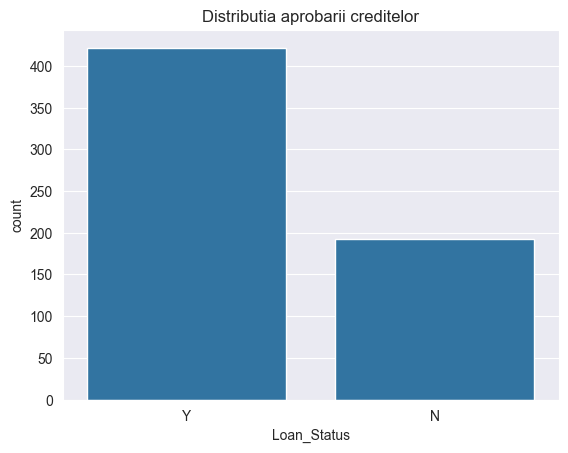

In [4]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Distributia aprobarii creditelor")
plt.show()

Mai jos se vede cum Credit_History are cea mai mare influenta asupra rezultatului.

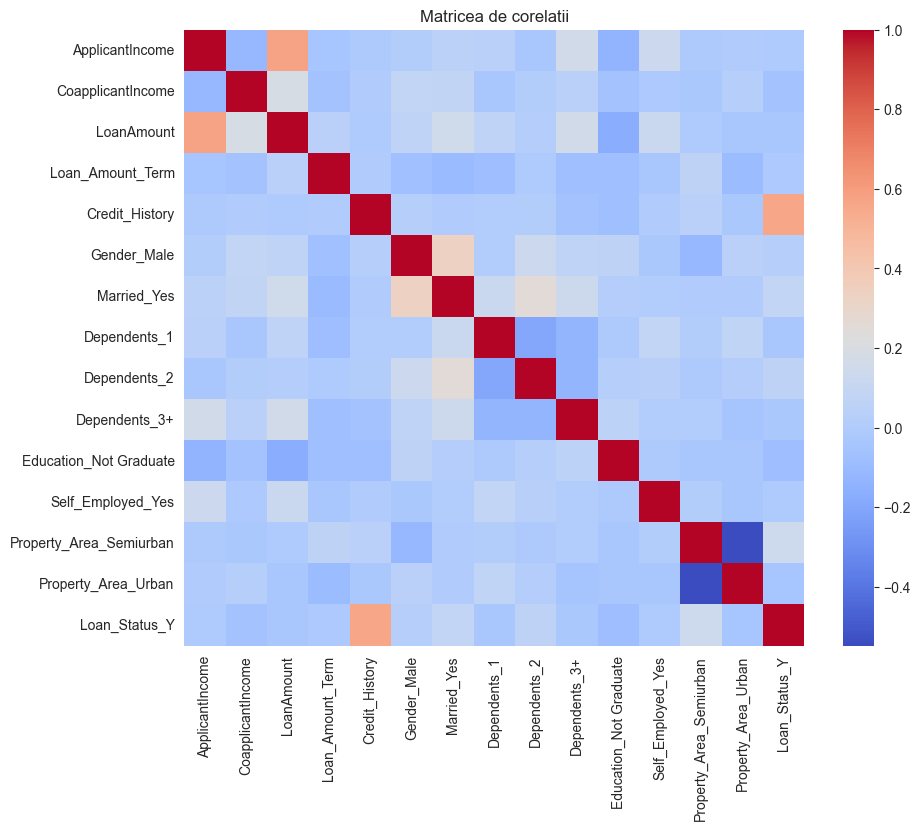

In [5]:
df = df.drop("Loan_ID", axis=1)

df_temp = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,8))
sns.heatmap(df_temp.corr(), cmap="coolwarm")
plt.title("Matricea de corelatii")
plt.show()

Am verificat sa nu mai existe valori de null in setul de date:

In [6]:
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})
df.fillna(df.mode().iloc[0], inplace=True)
df = pd.get_dummies(df, drop_first=True)

df.isna().sum()

ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
Gender_Male                0
Married_Yes                0
Dependents_1               0
Dependents_2               0
Dependents_3+              0
Education_Not Graduate     0
Self_Employed_Yes          0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64

In [7]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)

Am folosit scalarea ca sa nu am valori extrem de mari (100,2000..), si sa le aduc valorile pana in 2.

In [8]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

X_train_scaled.head()
X_test_scaled.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.598525,-0.603933,0.969893,0.30117,0.409283,0.486373,0.765641,-0.441367,-0.427223,-0.304363,-0.533775,-0.391002,1.264464,-0.7025
1,-0.194695,-0.603933,-0.193101,0.30117,0.409283,0.486373,0.765641,-0.441367,-0.427223,-0.304363,-0.533775,-0.391002,1.264464,-0.7025
2,-0.218460,-0.054855,0.139183,0.30117,0.409283,0.486373,0.765641,-0.441367,2.340699,-0.304363,-0.533775,-0.391002,-0.790849,-0.7025
3,-0.429022,-0.603933,-0.893272,0.30117,0.409283,-2.056033,-1.306094,-0.441367,-0.427223,-0.304363,-0.533775,-0.391002,-0.790849,-0.7025
4,-0.459268,-0.603933,-0.905139,0.30117,0.409283,0.486373,-1.306094,-0.441367,-0.427223,-0.304363,-0.533775,-0.391002,1.264464,-0.7025


Mai jos se vede dezechilibrul intre date:

In [9]:
y.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

Am folost SMOTE ca sa echilibrez datele:

In [10]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [11]:
y_train_balanced.value_counts()

Loan_Status
1    322
0    322
Name: count, dtype: int64

Graficul de mai jos arata rezultatul balansarii

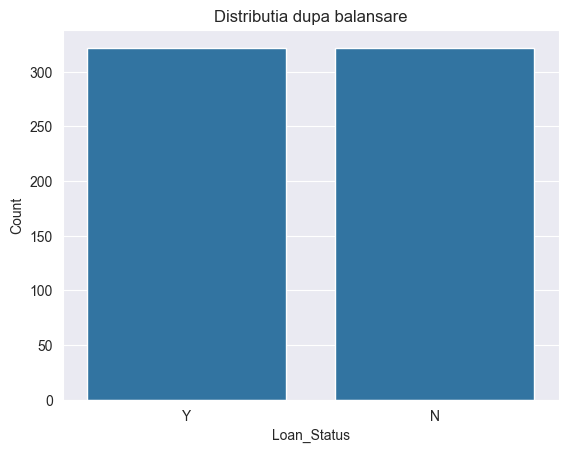

In [12]:
sns.countplot(x=y_train_balanced.map({1: "Y", 0: "N"}))
plt.title("Distributia dupa balansare")
plt.xlabel("Loan_Status")
plt.ylabel("Count")
plt.show()

In [13]:
def evaluate_model(name: str, model, X_train, X_test, y_train, y_test) -> dict:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

# verifica daca modelul are probabilitati
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

## Interpretarea matricilor de confuzie

Toate modelele prezinta un numar ridicat de predictii corecte pentru clasa pozitiva (credite aprobate), insa intampina dificultati in identificarea clasei negative (credite respinse). Acest lucru indica o tendinta generala de a favoriza aprobarea creditelor.

### Decision Tree
Modelul face un numar relativ mare de erori atat pentru clasa negativa, cat si pentru cea pozitiva. Performanta este moderata si instabila.

### Random Forest
Imbunatateste semnificativ rezultatele fata de Decision Tree, avand mai putine erori si o capacitate mai buna de generalizare.

### XGBoost
Ofera un echilibru bun intre predictiile corecte si erori, insa inca rateaza unele cazuri din clasa negativa.

### CatBoost
Are performanta foarte buna, cu multe predictii corecte pentru clasa pozitiva si mai putine erori comparativ cu alte modele.

### EBM
Prezinta rezultate similare cu XGBoost, dar cu o usoara tendinta de a face mai multe erori pe clasa negativa.

### Logistic Regression
Model simplu si eficient, dar cu performante mai slabe comparativ cu modelele ensemble.

### SVM
Are performanta decenta, insa intampina dificultati in clasificarea corecta a clasei negative.

### KNN
Rezultate similare cu SVM, dar usor mai slabe, cu mai multe erori de clasificare.

### Naive Bayes
Are cel mai bun recall pentru clasa pozitiva (identifica aproape toate creditele aprobate), dar tinde sa clasifice prea multe cazuri ca fiind pozitive.

## Concluzie
Modelele de tip ensemble (Random Forest, XGBoost, CatBoost) ofera cele mai bune rezultate generale. Naive Bayes are cea mai buna capacitate de a detecta clasa pozitiva, dar cu riscul de a supraestima aprobarile. In general, toate modelele intampina dificultati in identificarea corecta a clasei negative.

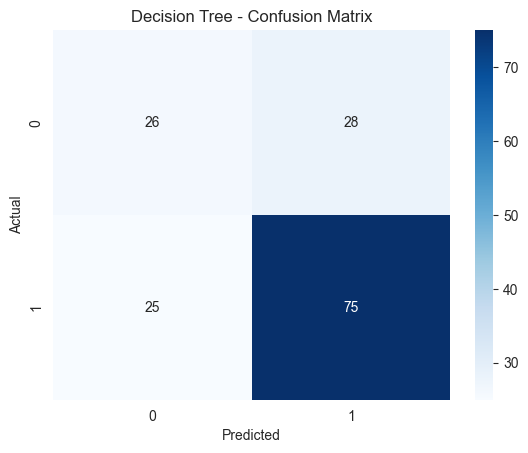

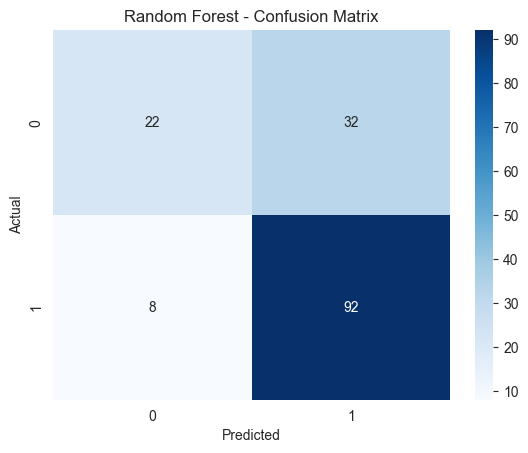

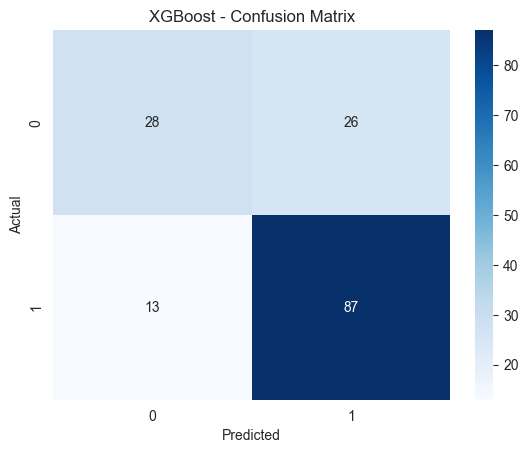

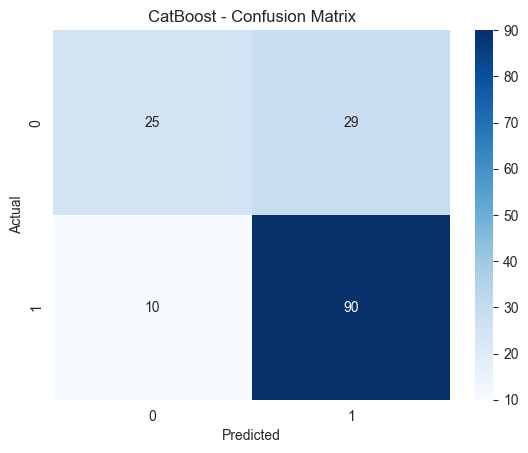

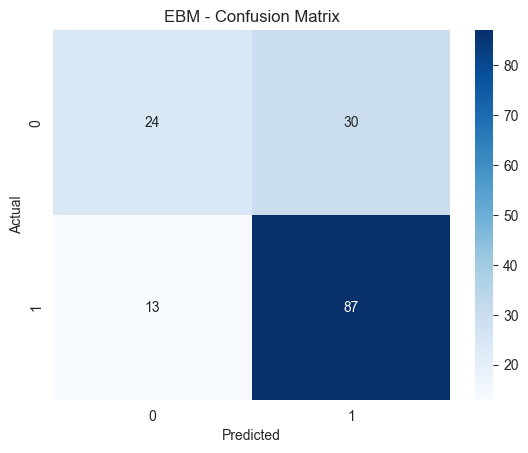

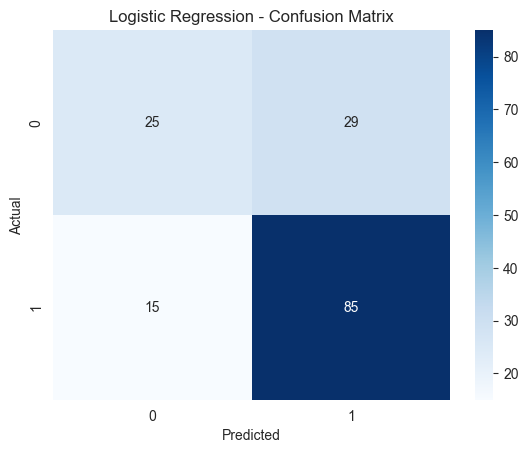

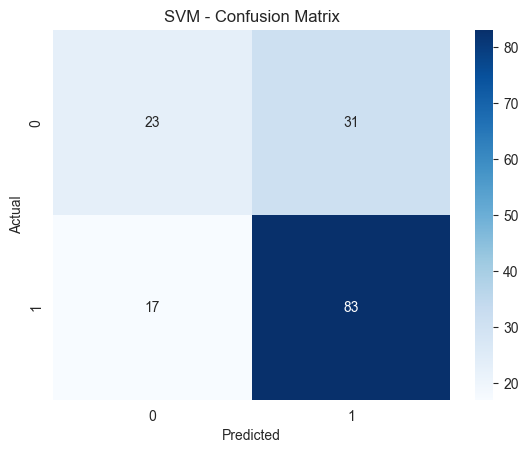

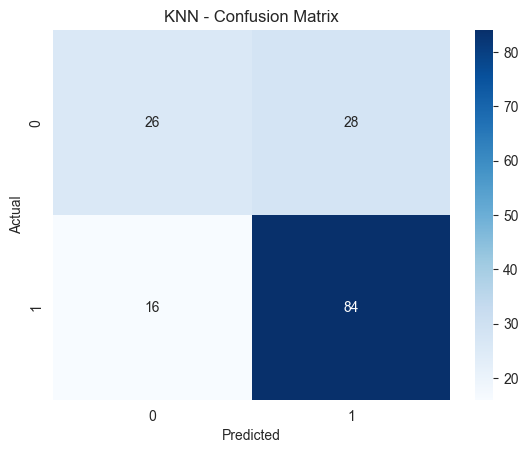

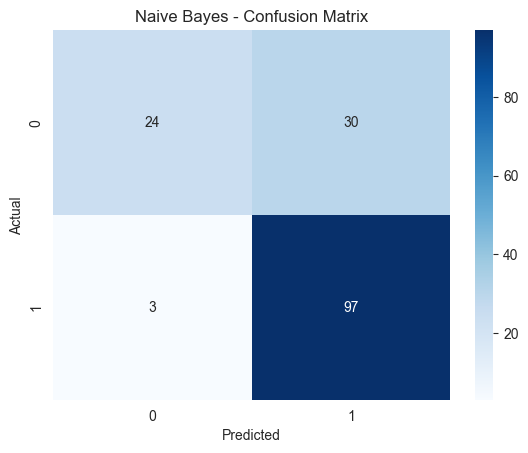

In [14]:
results = []

# toate modelele folosesc scaled (pentru consistenta)
results.append(evaluate_model("Decision Tree",
                              DecisionTreeClassifier(random_state=42),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

results.append(evaluate_model("Random Forest",
                              RandomForestClassifier(random_state=42),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

results.append(evaluate_model("XGBoost",
                              XGBClassifier(eval_metric='logloss', random_state=42),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

results.append(evaluate_model("CatBoost",
                              CatBoostClassifier(verbose=0),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

results.append(evaluate_model("EBM",
                              ExplainableBoostingClassifier(),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

results.append(evaluate_model("Logistic Regression",
                              LogisticRegression(max_iter=2000),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

results.append(evaluate_model("SVM",
                              SVC(probability=True),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

results.append(evaluate_model("KNN",
                              KNeighborsClassifier(),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

results.append(evaluate_model("Naive Bayes",
                              GaussianNB(),
                              X_train_balanced, X_test_scaled,
                              y_train_balanced, y_test))

In [15]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False)

print(results_df)

                 Model  Accuracy  Precision  Recall        F1   ROC_AUC
8          Naive Bayes  0.785714   0.763780    0.97  0.854626  0.722963
3             CatBoost  0.746753   0.756303    0.90  0.821918  0.728519
1        Random Forest  0.740260   0.741935    0.92  0.821429  0.782685
2              XGBoost  0.746753   0.769912    0.87  0.816901  0.747778
4                  EBM  0.720779   0.743590    0.87  0.801843  0.730000
5  Logistic Regression  0.714286   0.745614    0.85  0.794393  0.709444
7                  KNN  0.714286   0.750000    0.84  0.792453  0.716574
6                  SVM  0.688312   0.728070    0.83  0.775701  0.718519
0        Decision Tree  0.655844   0.728155    0.75  0.738916  0.615741


In [16]:
top5 = results_df.head(5)

print("TOP 5 MODELE:")
print(top5)

TOP 5 MODELE:
           Model  Accuracy  Precision  Recall        F1   ROC_AUC
8    Naive Bayes  0.785714   0.763780    0.97  0.854626  0.722963
3       CatBoost  0.746753   0.756303    0.90  0.821918  0.728519
1  Random Forest  0.740260   0.741935    0.92  0.821429  0.782685
2        XGBoost  0.746753   0.769912    0.87  0.816901  0.747778
4            EBM  0.720779   0.743590    0.87  0.801843  0.730000


## 4.4 Ajustarea hiperparametrilor

Pentru imbunatatirea performantelor modelelor, am utilizat metoda GridSearchCV, care permite testarea sistematica a mai multor combinatii de hiperparametri si selectarea celor optime pe baza scorului F1.

Am definit intervale relevante pentru fiecare model, tinand cont de rolul hiperparametrilor in controlul complexitatii si capacitatii de generalizare. De exemplu, pentru modelele ensemble (Random Forest, XGBoost, CatBoost) am ajustat parametri precum numarul de estimatori, adancimea arborilor si rata de invatare, iar pentru Naive Bayes am optimizat parametrul de regularizare var_smoothing.



In [17]:
def tune_model(name, model, param_grid, X_train, y_train):
    grid = GridSearchCV(
        model,
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print(f"{name} BEST PARAMS:", grid.best_params_)

    return grid.best_estimator_

In [18]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

xgb_best = tune_model(
    "XGBoost",
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_params,
    X_train_balanced,
    y_train_balanced
)

XGBoost BEST PARAMS: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}


In [19]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10]
}

rf_best = tune_model(
    "Random Forest",
    RandomForestClassifier(random_state=42),
    rf_params,
    X_train_balanced,
    y_train_balanced
)

Random Forest BEST PARAMS: {'max_depth': None, 'n_estimators': 200}


In [20]:
cat_params = {
    'depth': [4, 6],
    'learning_rate': [0.03, 0.1],
    'iterations': [100, 200]
}

cat_best = tune_model(
    "CatBoost",
    CatBoostClassifier(verbose=0),
    cat_params,
    X_train_balanced,
    y_train_balanced
)

CatBoost BEST PARAMS: {'depth': 6, 'iterations': 200, 'learning_rate': 0.03}


In [21]:
ebm_params = {
    'max_bins': [128, 256],
    'learning_rate': [0.01, 0.05],
    'interactions': [0]
}

ebm_best = tune_model(
    "EBM",
    ExplainableBoostingClassifier(interactions=0),
    ebm_params,
    X_train_balanced,
    y_train_balanced
)

EBM BEST PARAMS: {'interactions': 0, 'learning_rate': 0.01, 'max_bins': 128}


In [22]:
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

nb_best = tune_model(
    "Naive Bayes",
    GaussianNB(),
    nb_params,
    X_train_balanced,
    y_train_balanced
)

Naive Bayes BEST PARAMS: {'var_smoothing': 1e-09}


## Interpretarea matricilor de confuzie (modele optimizate)

Dupa optimizarea hiperparametrilor, modelele prezinta o imbunatatire generala a performantelor, in special in reducerea erorilor pentru clasa pozitiva. Totusi, dificultatea in clasificarea corecta a clasei negative ramane o problema comuna.

### Naive Bayes Tuned
Modelul are cel mai bun recall pentru clasa pozitiva, reusind sa identifice aproape toate creditele aprobate (foarte putine false negative). Totusi, face un numar mai mare de erori pentru clasa negativa, clasificand frecvent credite respinse ca fiind aprobate.

### CatBoost Tuned
Ofera un echilibru foarte bun intre clase, cu un numar redus de erori si o performanta ridicata pentru clasa pozitiva. Este unul dintre cele mai stabile modele.

### Random Forest Tuned
Prezinta rezultate foarte bune, cu putine erori pentru clasa pozitiva si o capacitate buna de generalizare. Totusi, continua sa faca erori in identificarea clasei negative.

### XGBoost Tuned
Are un echilibru bun intre predictiile corecte si erori, dar performanta este usor mai slaba comparativ cu Random Forest si CatBoost, in special pentru clasa negativa.

### EBM Tuned
Model interpretabil cu performante apropiate de celelalte modele ensemble, dar cu mai multe erori fata de Random Forest si CatBoost.

## Concluzie
Modelele optimizate confirma superioritatea metodelor ensemble. Random Forest si CatBoost ofera cele mai bune rezultate generale, combinand un numar ridicat de predictii corecte cu o stabilitate buna. Naive Bayes ramane modelul cu cel mai bun recall pentru clasa pozitiva, dar cu riscul de a supraestima aprobarile.

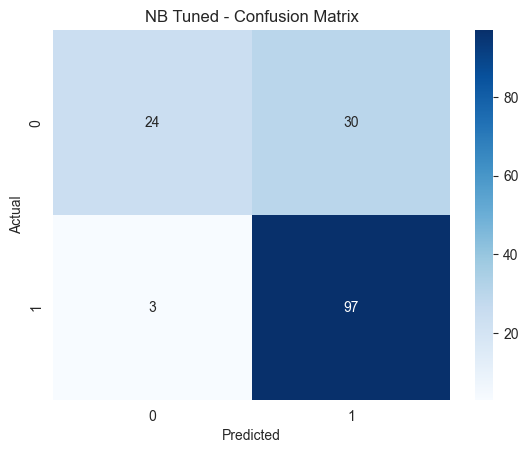

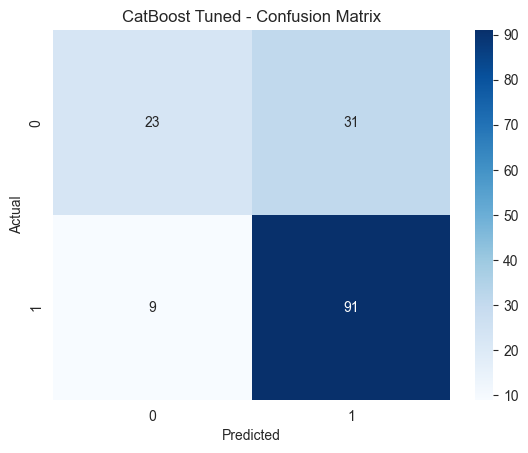

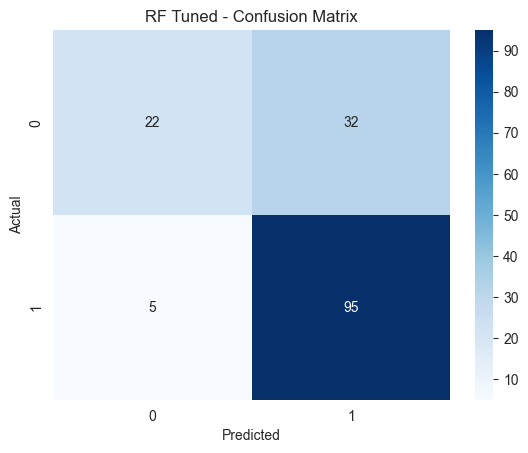

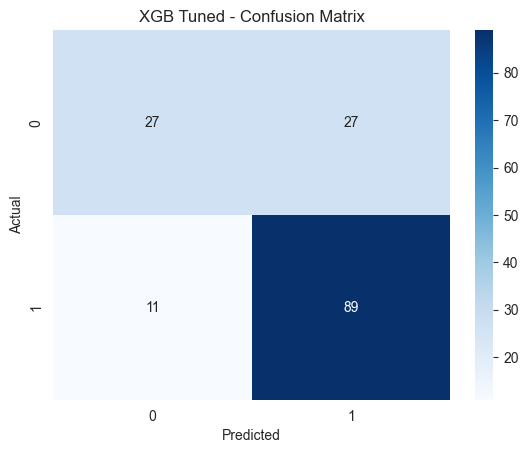

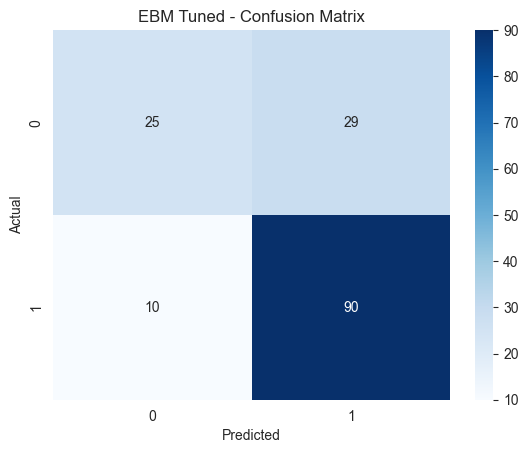

            Model  Accuracy  Precision  Recall        F1   ROC_AUC
0        NB Tuned  0.785714   0.763780    0.97  0.854626  0.722963
2        RF Tuned  0.759740   0.748031    0.95  0.837004  0.778611
3       XGB Tuned  0.753247   0.767241    0.89  0.824074  0.735000
4       EBM Tuned  0.746753   0.756303    0.90  0.821918  0.697407
1  CatBoost Tuned  0.740260   0.745902    0.91  0.819820  0.710741


['models/scaler_class.pkl']

In [23]:
tuned_results = []

tuned_results.append(evaluate_model("NB Tuned", nb_best,
                                   X_train_balanced, X_test_scaled,
                                   y_train_balanced, y_test))

tuned_results.append(evaluate_model("CatBoost Tuned", cat_best,
                                   X_train_balanced, X_test_scaled,
                                   y_train_balanced, y_test))

tuned_results.append(evaluate_model("RF Tuned", rf_best,
                                   X_train_balanced, X_test_scaled,
                                   y_train_balanced, y_test))

tuned_results.append(evaluate_model("XGB Tuned", xgb_best,
                                   X_train_balanced, X_test_scaled,
                                   y_train_balanced, y_test))

tuned_results.append(evaluate_model("EBM Tuned", ebm_best,
                                   X_train_balanced, X_test_scaled,
                                   y_train_balanced, y_test))

tuned_df = pd.DataFrame(tuned_results).sort_values(by="F1", ascending=False)

print(tuned_df)

# modele finale
joblib.dump(rf_best, "models/rf_class.pkl")
joblib.dump(xgb_best, "models/xgb_class.pkl")
joblib.dump(cat_best, "models/cat_class.pkl")
joblib.dump(ebm_best, "models/ebm_class.pkl")
joblib.dump(nb_best, "models/nb_class.pkl")

# features
joblib.dump(X.columns.tolist(), "models/features_class.pkl")

# scaler
joblib.dump(scaler, "models/scaler_class.pkl")

In [34]:
from sklearn.model_selection import StratifiedKFold

def plot_learning_curve(model, title, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Train")
    plt.plot(train_sizes, val_mean, label="Validation")
    plt.title(title)
    plt.xlabel("Training size")
    plt.ylabel("F1 score")
    plt.legend()
    plt.show()

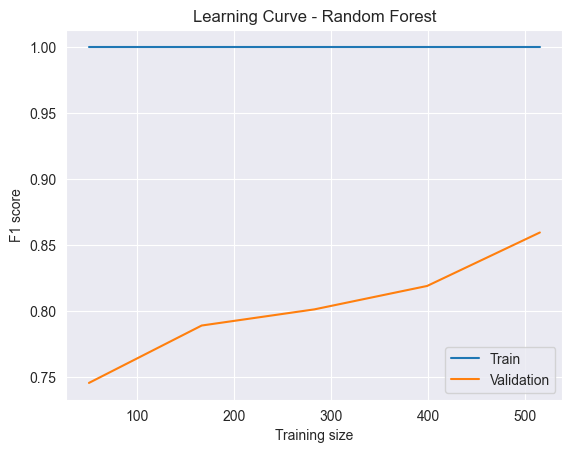

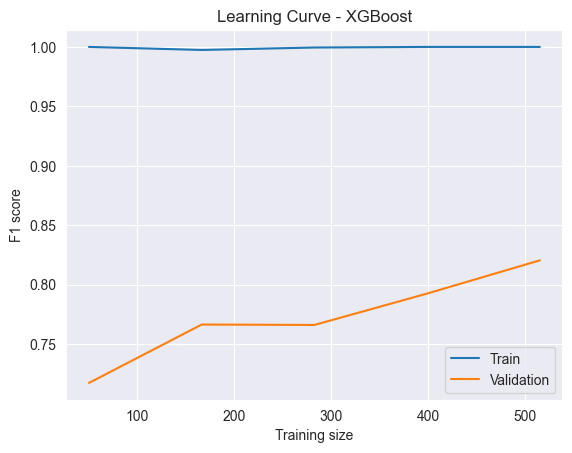

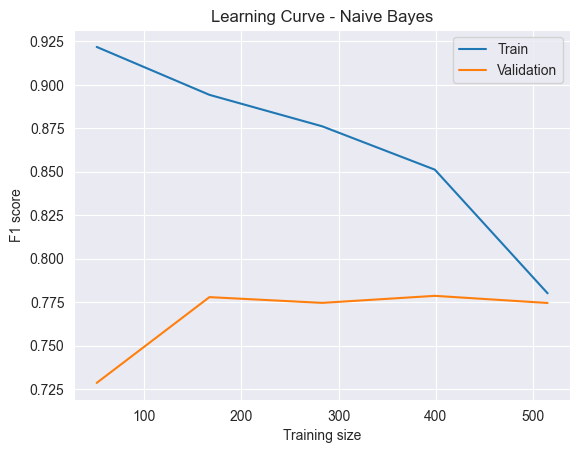

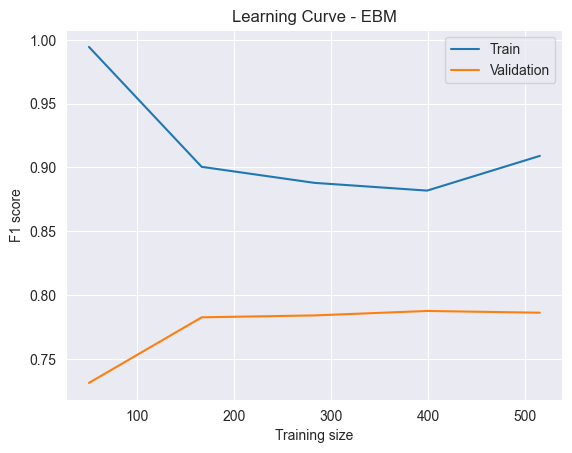

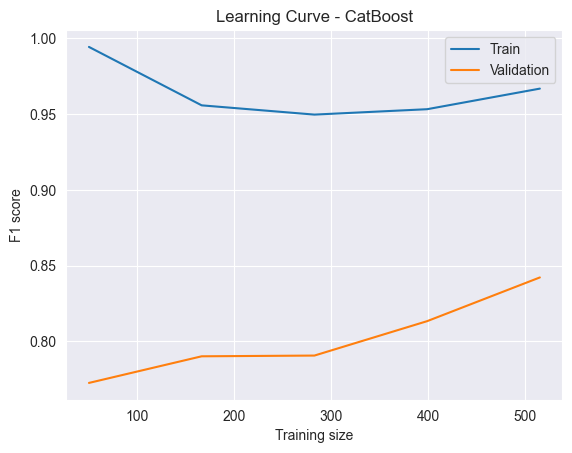

In [35]:
# Random Forest
plot_learning_curve(
    RandomForestClassifier(random_state=42),
    "Learning Curve - Random Forest",
    X_train_balanced,
    y_train_balanced
)

# XGBoost
plot_learning_curve(
    XGBClassifier(eval_metric='logloss', random_state=42),
    "Learning Curve - XGBoost",
    X_train_balanced,
    y_train_balanced
)

# Naive Bayes
plot_learning_curve(
    GaussianNB(),
    "Learning Curve - Naive Bayes",
    X_train_balanced,
    y_train_balanced
)

# EBM
plot_learning_curve(
    ExplainableBoostingClassifier(),
    "Learning Curve - EBM",
    X_train_balanced,
    y_train_balanced
)

# CatBoost
plot_learning_curve(
    CatBoostClassifier(verbose=0),
    "Learning Curve - CatBoost",
    X_train_balanced,
    y_train_balanced
)

## 4.5 Curbele de invatare - analiza

Curbele de invatare evidentiaza modul in care performanta modelelor evolueaza in functie de dimensiunea setului de antrenare, precum si diferentele dintre scorurile pe datele de train si cele de validare.

### Random Forest
Modelul obtine un scor perfect pe datele de antrenare (F1 ~ 1), ceea ce indica un posibil overfitting. Curba de validare creste constant odata cu dimensiunea setului de date, ajungand la aproximativ 0.86, dar ramane semnificativ sub cea de train.
Acest comportament sugereaza ca modelul invata foarte bine datele de antrenare, dar nu generalizeaza perfect.

### XGBoost
Similar cu Random Forest, modelul obtine scoruri foarte mari pe datele de train (aproape de 1), indicand overfitting. Curba de validare creste treptat si se stabilizeaza in jurul valorii de 0.82.
Modelul are o capacitate buna de invatare, dar exista in continuare un gap intre train si validation, ceea ce indica o usoara suprainvatare.

### Naive Bayes
Spre deosebire de modelele ensemble, scorul pe train scade pe masura ce creste dimensiunea setului de date, iar scorul de validare ramane relativ constant (in jur de 0.77).
Curbele sunt apropiate, ceea ce indica un model stabil, dar cu o capacitate limitata de invatare (underfitting).

### EBM
Modelul prezinta un scor ridicat pe train la inceput, care scade usor pe masura ce creste setul de date. Curba de validare creste si se stabilizeaza in jurul valorii de 0.78.
Exista un mic gap intre train si validation, dar modelul este relativ bine echilibrat intre bias si varianta.

### CatBoost
Modelul obtine scoruri foarte ridicate pe train (~0.95–0.98), iar scorul de validare creste constant pana la aproximativ 0.84
Diferenta dintre train si validation indica un usor overfitting, dar mai redus comparativ cu Random Forest si XGBoost.

## Concluzie
Modelele ensemble (Random Forest, XGBoost, CatBoost) tind sa supra-invete datele (overfitting), avand scoruri foarte mari pe train si mai mici pe validare. Cu toate acestea, ele obtin cele mai bune performante generale.
Naive Bayes prezinta underfitting, avand performante similare pe train si validation, dar la un nivel mai scazut.
EBM si CatBoost ofera un compromis mai bun intre bias si varianta, fiind modele mai echilibrate.
In general, cresterea dimensiunii setului de antrenare duce la imbunatatirea performantelor pe validare, ceea ce sugereaza ca modelele ar beneficia de mai multe date.

## 4.6 Explicabilitatea si analiza SHAP

Analiza a fost efectuata pentru primele 3 modele dupa performanta: Random Forest ,XGBBoost si Naive Bayes si am urmarit diferenta dintre acestea prin rezultatele graficelor.

### Summary Plot

Graficul arata importanta globala a variabilelor si distributia impactului acestora.

**Credit_History** este de departe cea mai importanta variabila, avand un impact foarte puternic asupra predictiei.
Valorile mari cresc probabilitatea aprobarii, iar valorile mici o reduc semnificativ.

Celelalte variabile (Property_Area_Semiurban, LoanAmount, ApplicantIncome) au influente mai reduse.


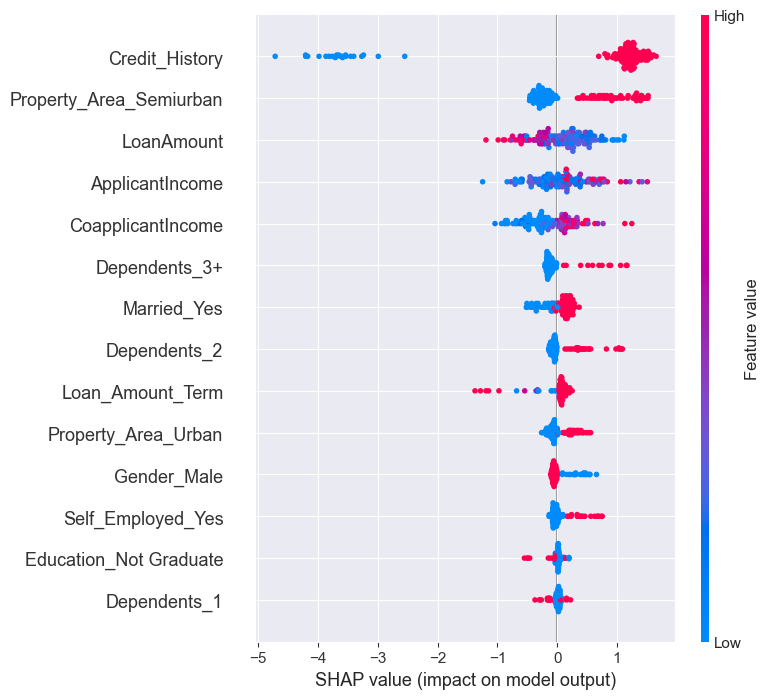

In [36]:
explainer_xgb = shap.Explainer(xgb_best, X_train_balanced)
shap_values_xgb = explainer_xgb(X_test_scaled)

# summary
shap.summary_plot(shap_values_xgb, X_test_scaled)

### Bar Plot

Graficul confirma importanta variabilelor.

**Credit_History domina modelul**, avand cea mai mare contributie.
Restul variabilelor au un impact mult mai mic, ceea ce arata ca modelul se bazeaza in principal pe aceasta caracteristica.


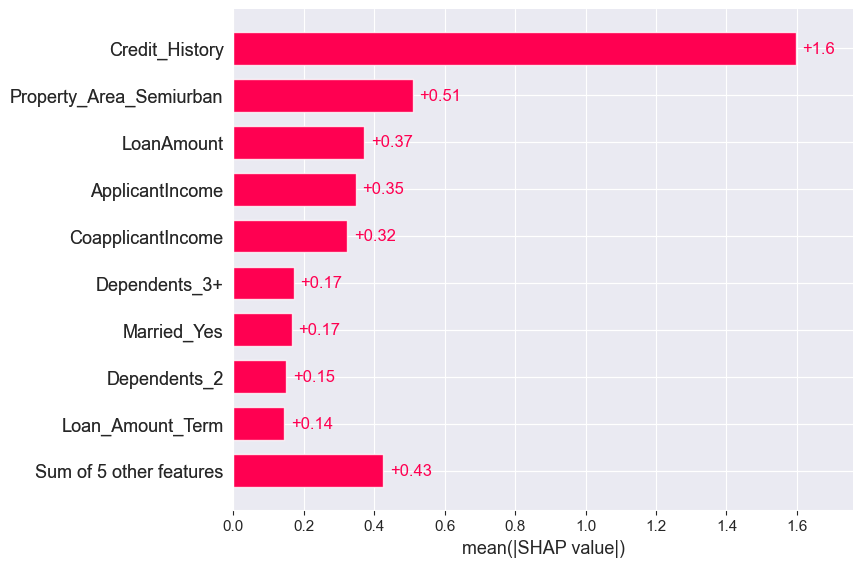

In [37]:
shap.plots.bar(shap_values_xgb)

### Waterfall Plot

Graficul explica predictia pentru o observatie individuala.

**Credit_History** are cea mai mare contributie pozitiva.
**LoanAmount** si **CoapplicantIncome** reduc predictia, iar celelalte variabile au efecte mai mici.

Predictia finala este rezultatul combinarii acestor influente.


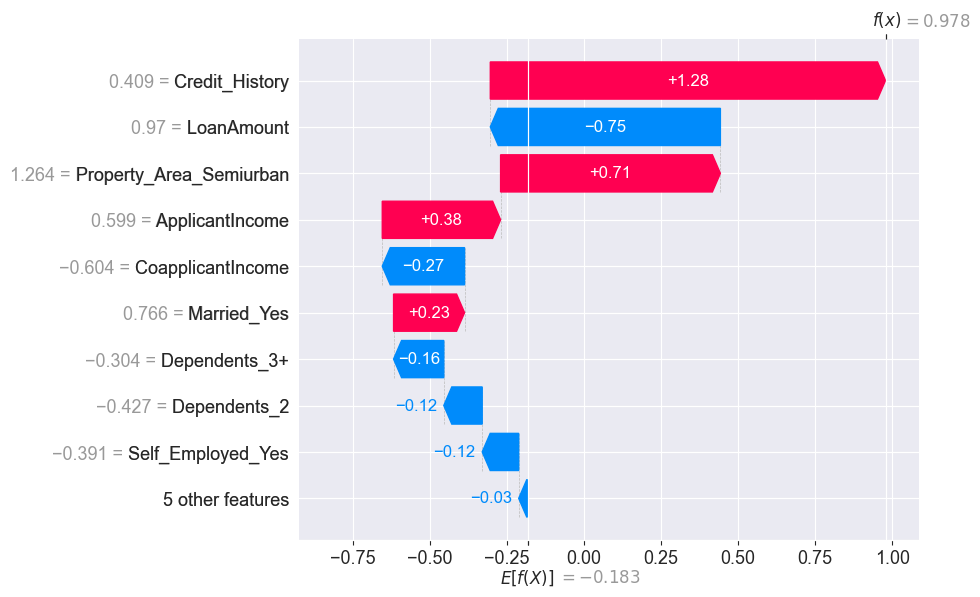

In [38]:
shap.plots.waterfall(shap_values_xgb[0])

### Force Plot

Graficul arata cum fiecare variabila influenteaza predictia.

Variabilele rosii cresc probabilitatea aprobarii, iar cele albastre o reduc.
**Credit_History** are cel mai mare impact pozitiv.


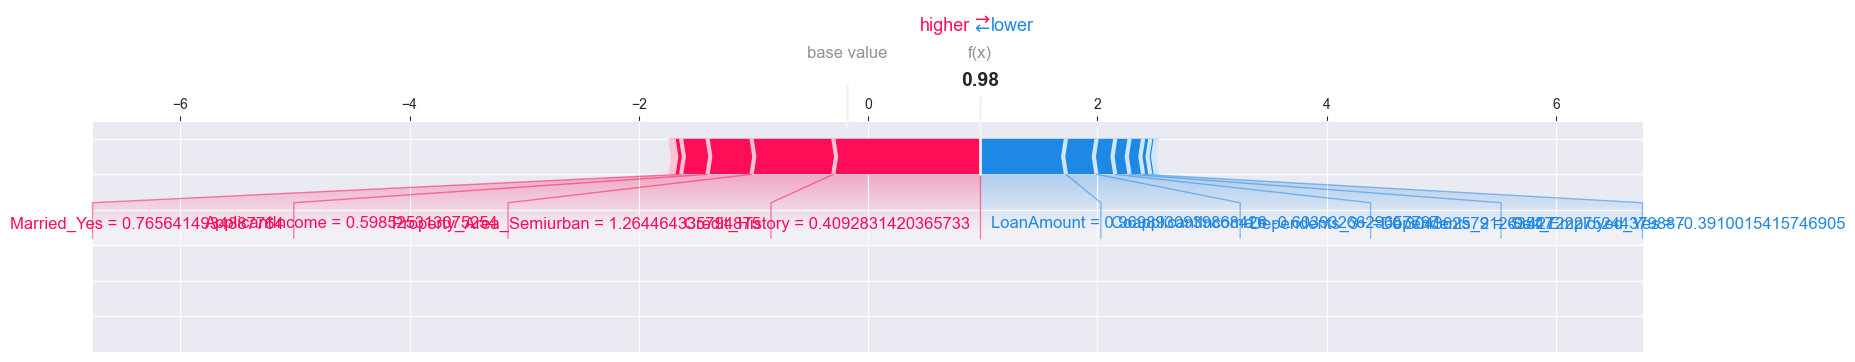

In [39]:
shap.force_plot(
    shap_values_xgb.base_values[0],
    shap_values_xgb.values[0],
    X_test_scaled.iloc[0],
    matplotlib=True
)

### Scatter Plot
#### Credit_History
Se observa o separare clara intre valori:

* 1 → impact pozitiv mare
* 0 → impact negativ puternic

Aceasta confirma ca este variabila cea mai importanta.

#### ApplicantIncome
Valorile sunt concentrate in jurul lui 0, ceea ce indica o influenta redusa.
Exista o usoara tendinta pozitiva pentru venituri mai mari, dar fara impact major.

#### LoanAmount
Se observa o relatie negativa:
valorile mari ale creditului reduc probabilitatea aprobarii.
Impactul este moderat comparativ cu Credit_History.



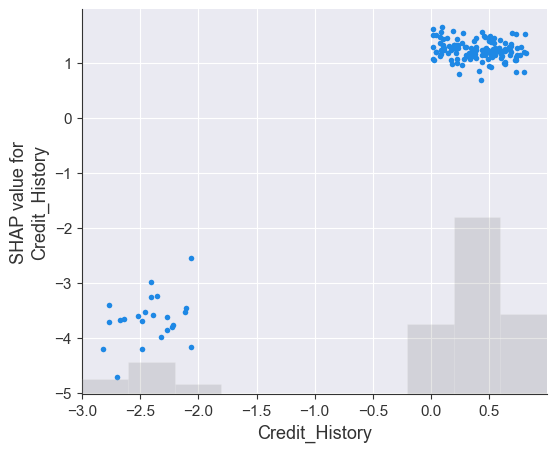

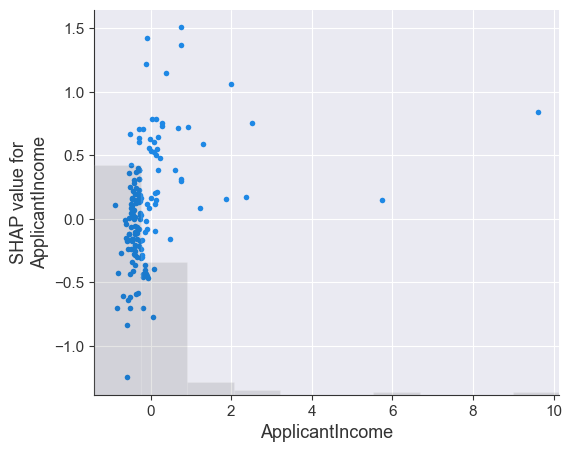

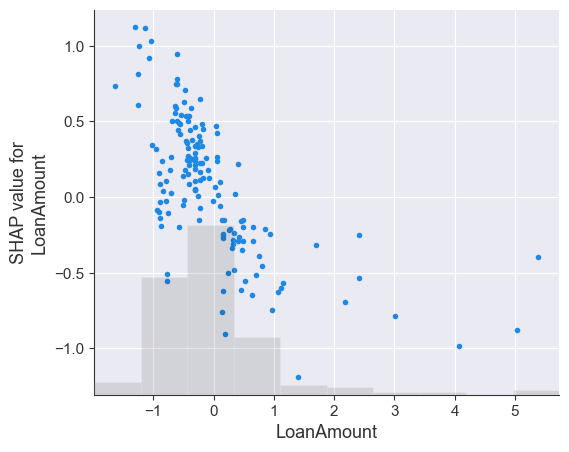

In [40]:
shap.plots.scatter(shap_values_xgb[:, "Credit_History"])
shap.plots.scatter(shap_values_xgb[:, "ApplicantIncome"])
shap.plots.scatter(shap_values_xgb[:, "LoanAmount"])

In [41]:
explainer_nb = shap.KernelExplainer(
    nb_best.predict_proba,
    X_train_balanced[:100]
)

shap_values_nb = explainer_nb.shap_values(X_test_scaled[:50])

100%|██████████| 50/50 [00:08<00:00,  6.06it/s]


### Summary Plot

Graficul arata ca **Credit_History este variabila dominanta**.

Se observa o separare clara:

* valori mari -> impact pozitiv
* valori mici -> impact negativ

Restul variabilelor sunt concentrate in jurul lui 0, ceea ce indica o influenta foarte redusa asupra modelului.


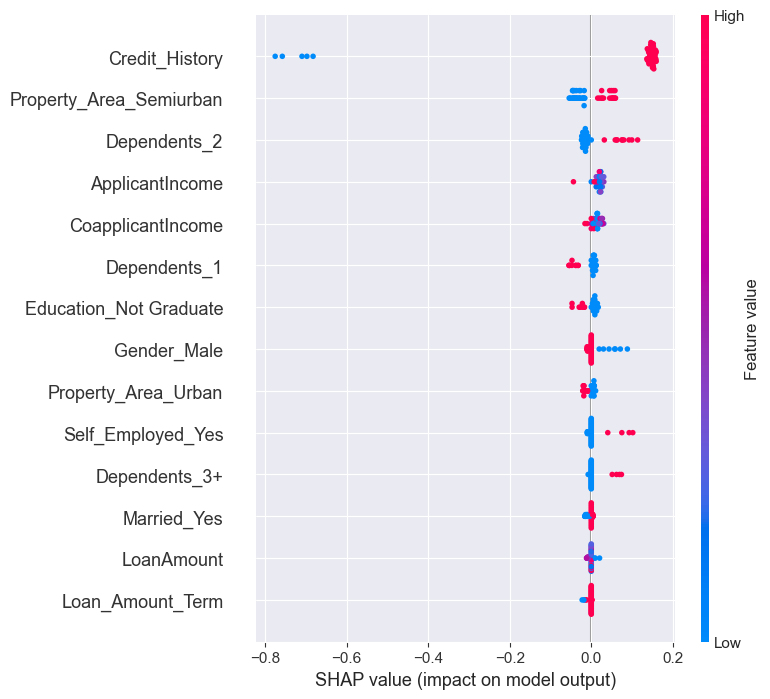

In [42]:
shap.summary_plot(shap_values_nb[:, :, 1], X_test_scaled[:50])

### Bar Plot

Graficul confirma ca modelul se bazeaza aproape exclusiv pe **Credit_History**.
Celelalte variabile (Property_Area_Semiurban, Dependents_2, ApplicantIncome) au contributii foarte mici, aproape neglijabile.


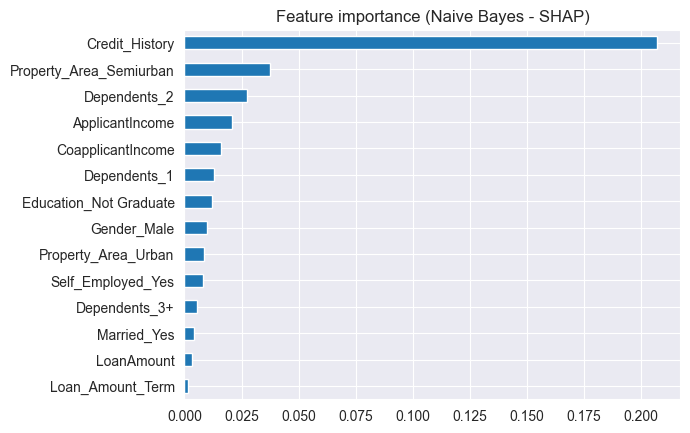

In [43]:
mean_abs_shap = np.abs(shap_values_nb[:, :, 1]).mean(axis=0)

feature_importance = pd.Series(mean_abs_shap, index=X_test_scaled.columns)
feature_importance.sort_values().plot(kind="barh")
plt.title("Feature importance (Naive Bayes - SHAP)")
plt.show()

### Waterfall Plot

Graficul arata contributiile pentru o observatie.

**Credit_History** are cea mai mare influenta pozitiva asupra predictiei.
Celelalte variabile contribuie foarte putin, unele pozitiv, altele negativ.

Predictia finala este determinata in principal de aceasta variabila.


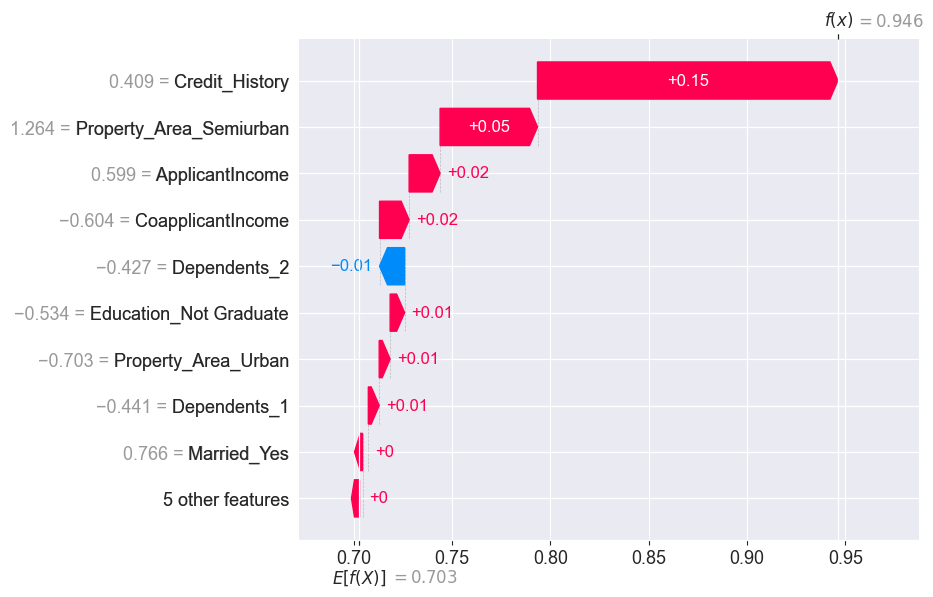

In [44]:
i = 0
expl = shap.Explanation(
    values=shap_values_nb[i, :, 1],
    base_values=explainer_nb.expected_value[1],
    data=X_test_scaled.iloc[i],
    feature_names=X_test_scaled.columns
)

shap.plots.waterfall(expl)

### Force Plot

Graficul evidentiaza aceeasi idee:
majoritatea influentei vine din **Credit_History**.

Celelalte variabile au efecte foarte mici si nu modifica semnificativ rezultatul.


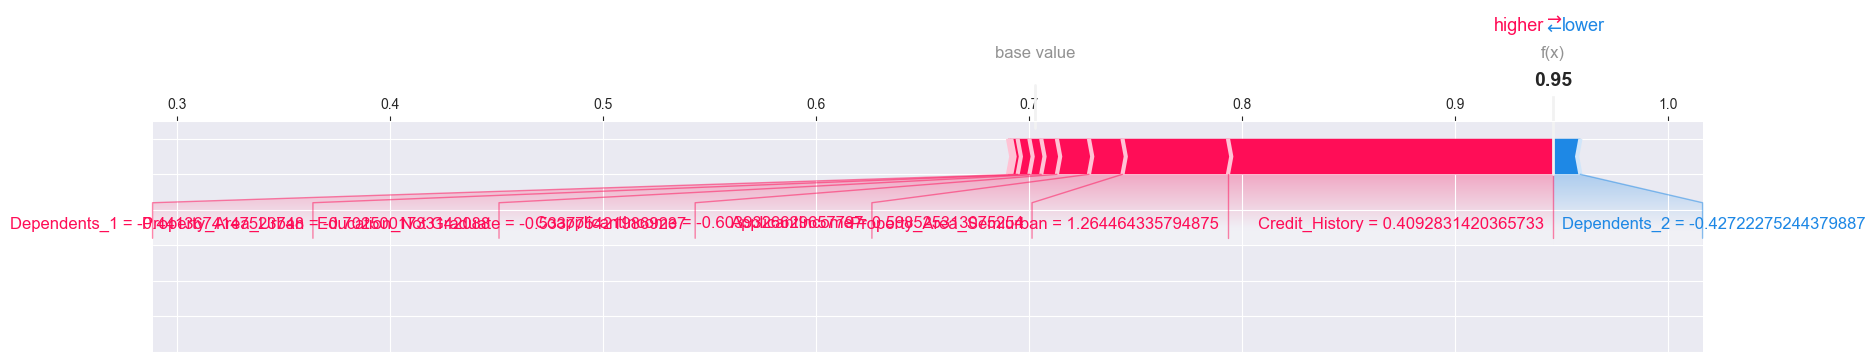

In [45]:

shap.force_plot(
    explainer_nb.expected_value[1],
    shap_values_nb[i, :, 1],
    X_test_scaled.iloc[i],
    matplotlib=True
)

### Scatter Plot
#### Credit_History

Se observa o separare foarte clara:

* valoarea 1 → impact pozitiv
* valoarea 0 → impact negativ

Aceasta confirma dependenta puternica a modelului de aceasta variabila.

#### ApplicantIncome
Valorile sunt concentrate foarte aproape de 0, ceea ce indica o influenta foarte slaba.
Nu exista o relatie clara intre venit si predictie.

#### LoanAmount

Valorile SHAP sunt foarte mici si distribuite in jurul lui 0.
Aceasta arata ca LoanAmount are un impact aproape inexistent asupra modelului Naive Bayes.

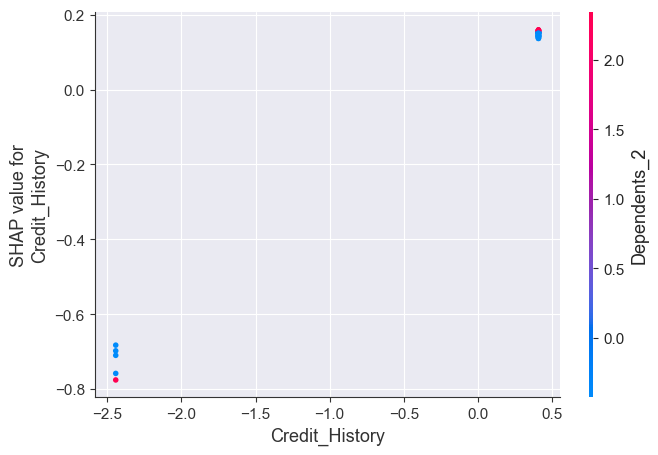

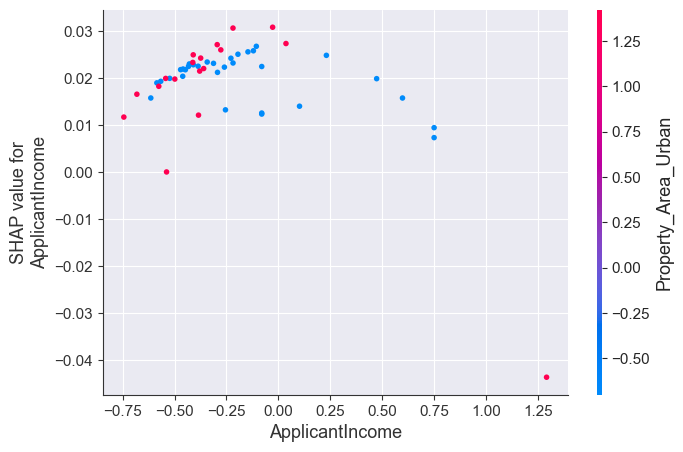

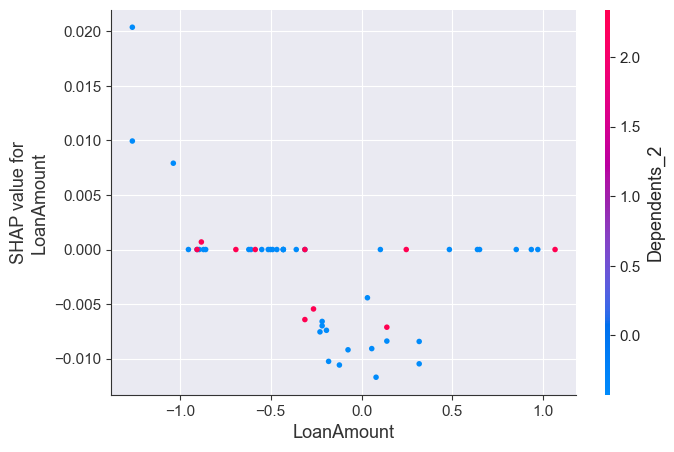

In [46]:
shap.dependence_plot("Credit_History", shap_values_nb[:, :, 1], X_test_scaled[:50])
shap.dependence_plot("ApplicantIncome", shap_values_nb[:, :, 1], X_test_scaled[:50])
shap.dependence_plot("LoanAmount", shap_values_nb[:, :, 1], X_test_scaled[:50])


### Summary Plot

**Credit_History** este cea mai importanta variabila, avand cel mai mare impact asupra predictiei.

Se observa ca:

* valori mari -> cresc sansele de aprobare
* valori mici -> scad sansele

Urmatoarele variabile importante sunt:

* Property_Area_Semiurban
* ApplicantIncome
* LoanAmount

Restul au impact mai redus.


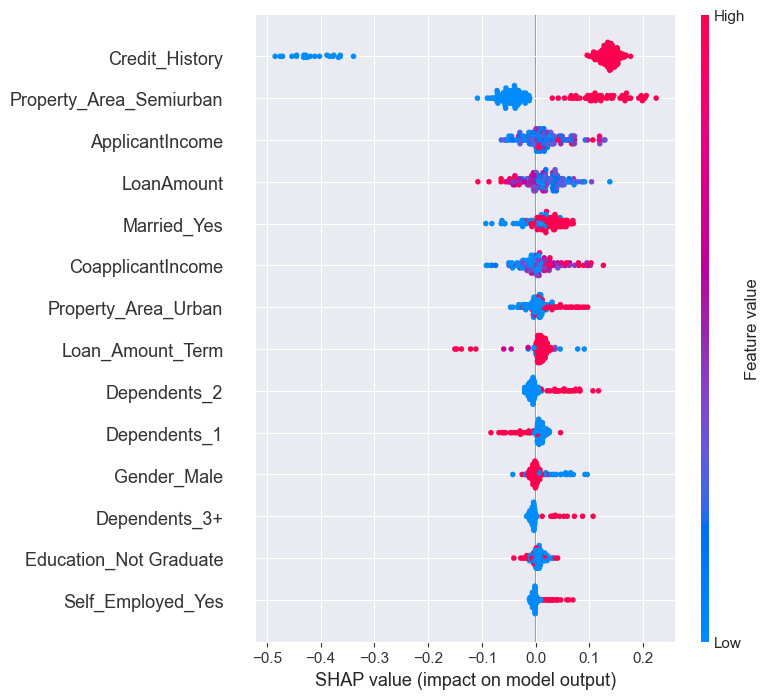

In [47]:
explainer_rf = shap.TreeExplainer(rf_best)
shap_values_rf = explainer_rf.shap_values(X_test_scaled)

shap.summary_plot(shap_values_rf[:, :, 1], X_test_scaled)

### Bar Plot

Graficul confirma importanta variabilelor:

* **Credit_History** domina clar modelul
* Property_Area_Semiurban este a doua ca importanta
* ApplicantIncome si LoanAmount au contributii moderate

Modelul foloseste mai multe variabile, nu doar una (spre deosebire de Naive Bayes).


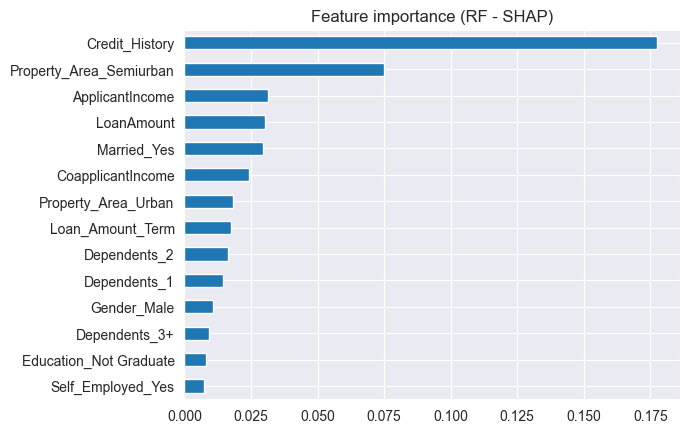

In [48]:
mean_abs = np.abs(shap_values_rf[:, :, 1]).mean(axis=0)

pd.Series(mean_abs, index=X_test_scaled.columns)\
    .sort_values()\
    .plot(kind="barh")

plt.title("Feature importance (RF - SHAP)")
plt.show()

### Waterfall Plot

Pentru aceasta observatie:

* **Credit_History** contribuie cel mai mult pozitiv
* Property_Area_Semiurban si Married_Yes cresc predictia
* LoanAmount si Dependents reduc usor scorul

Predictia finala este rezultatul combinatiei acestor factori.


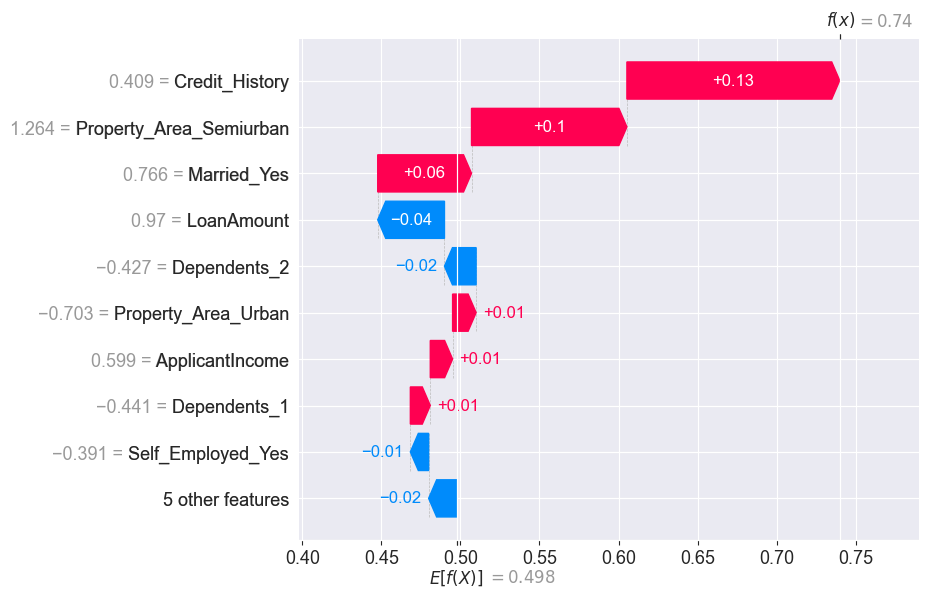

In [49]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_rf[0, :, 1],
        base_values=explainer_rf.expected_value[1],
        data=X_test_scaled.iloc[0],
        feature_names=X_test_scaled.columns
    )
)

### Force Plot

Graficul arata cum variabilele imping predictia:

* rosu → creste probabilitatea aprobarii
* albastru → o scade

**Credit_History si Property_Area_Semiurban** sunt principalele forte pozitive, in timp ce LoanAmount si Dependents trag predictia in jos.


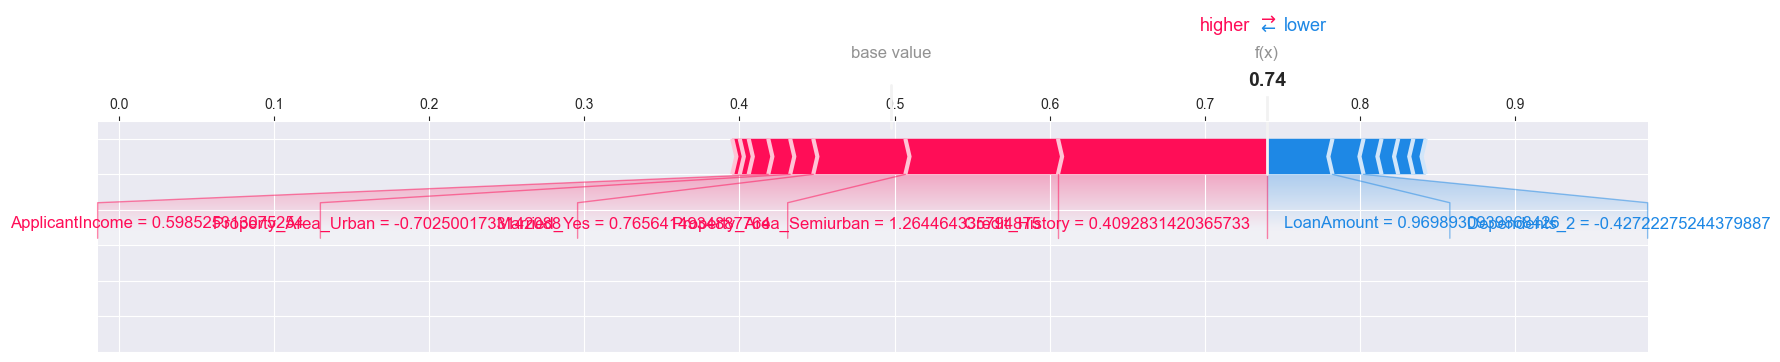

In [50]:
shap.force_plot(
    explainer_rf.expected_value[1],
    shap_values_rf[0, :, 1],
    X_test_scaled.iloc[0],
    matplotlib=True
)

### Scatter Plot
#### Credit_History

Se observa o separare clara:

* valori mari → SHAP pozitiv
* valori mici → SHAP negativ

Aceasta confirma ca este cea mai influenta variabila in model.

#### ApplicantIncome
Impactul este moderat:

valori mai mari tind sa creasca usor predictia
dar exista dispersie → relatia nu este foarte puternica

Deci influenta este reala, dar limitata.

#### LoanAmount
Se observa o relatie inversa:

valori mari → impact negativ
valori mici → impact pozitiv

Cu alte cuvinte, imprumuturile mai mari reduc sansele de aprobare.


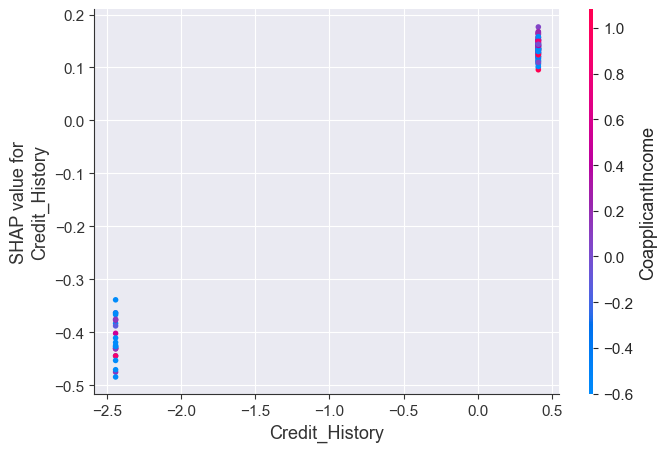

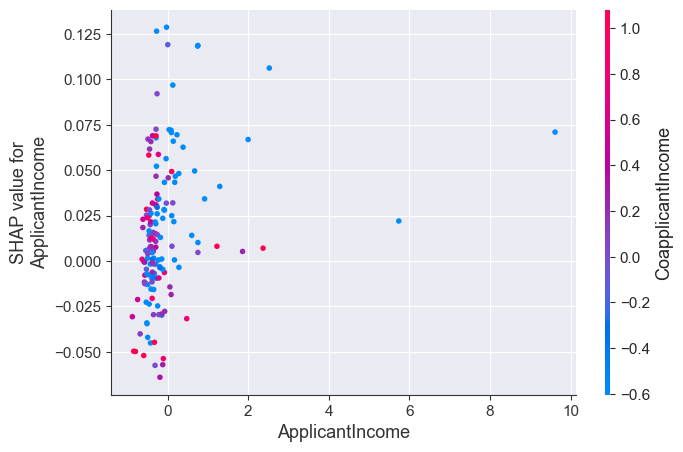

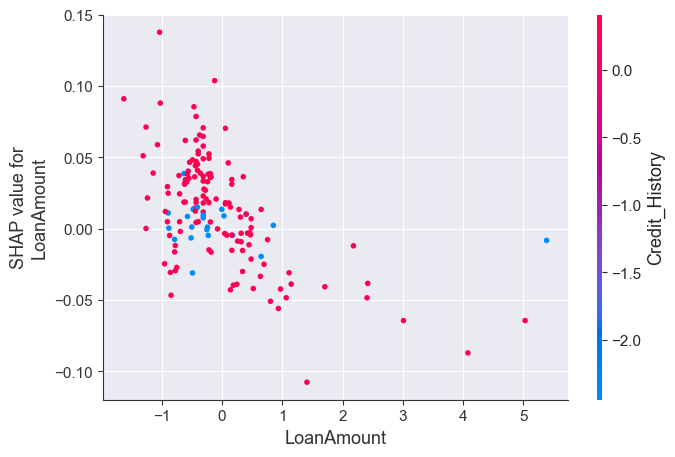

In [51]:
shap.dependence_plot("Credit_History", shap_values_rf[:, :, 1], X_test_scaled)
shap.dependence_plot("ApplicantIncome", shap_values_rf[:, :, 1], X_test_scaled)
shap.dependence_plot("LoanAmount", shap_values_rf[:, :, 1], X_test_scaled)

## Concluzie privind comportamentul modelelor

Analiza SHAP arata ca toate modelele identifica aceleasi caracteristici esentiale, in special *Credit_History*, *Property_Area_Semiurban*, *ApplicantIncome* si *LoanAmount*, ceea ce indica consistenta si o invatare corecta a relatiilor din date.

Modelele de tip ensemble (Random Forest, XGBoost, CatBoost) ofera cele mai bune rezultate, reusind sa surprinda mai bine relatiile complexe dintre variabile, in timp ce modele mai simple precum Naive Bayes tind sa simplifice excesiv aceste relatii.

In concluzie, modelele obtin performante bune si interpretari coerente, iar utilizarea SHAP contribuie semnificativ la intelegerea factorilor care influenteaza decizia de aprobare a creditului.
